# EEG_38 — Small-Vocabulary DHSLP (5 parole)

**Domanda**: i paper che riportano ~78% (Li et al. 2025) e in generale la letteratura
imagined-speech (44–96%, vedi Panachakel & Ramakrishnan 2021) usano **vocabolari piccoli**.
Restringendo da 110→4 cluster a **~5 parole singole**, l'accuratezza risale verso quei numeri?

**Perché subject-INDEPENDENT (non subject-specific)**: su questo dataset ogni parola ha solo
**5 ripetizioni per soggetto** (una per sessione). 5 parole → 25 trial/soggetto: troppo pochi per
allenare un modello deep subject-specific. La letteratura small-vocab ha decine/centinaia di
ripetizioni per parola; noi no. Quindi si pool cross-subject: 5 parole × 5 sessioni × 50 soggetti
train ≈ 1250 trial. È la versione **rigorosa** della domanda: *il vocabolario piccolo aiuta il
trasferimento cross-subject?*

**Confronto**: chance = 1/K (20% per 5 parole). Riferimenti: EEG_35 baseline concr4 (4-cls)
test ≈ 25.6% (chance 25%); EEG_13b S-Spec best 39% (chance 25%).

**Atteso onesto**: vicino a 20% (chance). Se esce ≥30% sarebbe un segnale forte che il
vocabolario era parte del problema.

In [1]:
# ====================== §0 — Config ======================
import json, logging, math, re, random
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score

try:
    import wandb; _HAS_WANDB = True
except Exception:
    _HAS_WANDB = False

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg38')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents)
                     if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N_CHANNELS = 61; N_SAMPLES = 384; DATA_METRIC = 'abs_pcc'

# --- Selezione parole (subset small-vocab) -------------------------------------
# Default: 5 parole massimamente distinte (significato spread su concr4 + onset/lunghezza diversi).
# Onset: a / b / f / d / g ; lunghezza varia ; una per categoria concr4 + 1.
WORDS = ['acqua', 'bere', 'felicità', 'domani', 'guerra']

# Opzionale: media su R subset random di K parole (stima non distorta del K-class decoding).
# Lascia RANDOM_SUBSETS=0 per usare solo WORDS. Es. RANDOM_SUBSETS=5, K_RANDOM=5.
RANDOM_SUBSETS = 5
K_RANDOM       = 5

# Split subject-independent (come EEG_35/37)
SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

# Architettura identica a EEG_35/37 baseline_dhslp
K_WINDOWS=8; T_WIN=N_SAMPLES//K_WINDOWS; N_EDGES=16; D_MODEL=64; D_ENC=128; N_LAYERS=2
DROPOUT=0.4; DROPEDGE=0.10; LR=1e-3; WEIGHT_DECAY=1e-3; BATCH_SIZE=64
MAX_EPOCHS=60; PATIENCE=12; WARMUP_EPOCHS=5; LABEL_SMOOTHING=0.1
SEEDS=[42, 123, 7]

WANDB_ENTITY='uras-daniele22-politecnico-di-milano'
WANDB_PROJECT='miralis-imagined-speech'
USE_WANDB=_HAS_WANDB

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2idx = json.loads((project_root/'configs'/'label_schemes'/'label2idx.json').read_text())
label2idx = {str(k): int(v) for k, v in label2idx.items()}
idx2word  = {v: k for k, v in label2idx.items()}

HG_ROOT = project_root / 'data' / f'hypergraphs_pruned_{DATA_METRIC}'
DATA_AVAILABLE = HG_ROOT.exists() and any(HG_ROOT.rglob('trial_*.pt'))
log.info(f'device={device}  DATA_AVAILABLE={DATA_AVAILABLE}')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
14:55:20 INFO     device=cuda  DATA_AVAILABLE=True


## §1 — Valida le parole e costruisci la mappa parola→label

In [2]:
# ====================== §1.1 — word -> new label (0..K-1) ======================
def build_word_map(words):
    missing = [w for w in words if w not in label2idx]
    if missing:
        log.warning(f'Parole NON trovate in label2idx (ignorate): {missing}')
    words = [w for w in words if w in label2idx]
    # mappa: word_idx (0..109) -> new_label (0..K-1)
    word2lab = {label2idx[w]: i for i, w in enumerate(words)}
    return words, word2lab

WORDS, WORD2LAB = build_word_map(WORDS)
N_CLASSES = len(WORDS)
CHANCE    = 1.0 / N_CLASSES
log.info(f'Parole ({N_CLASSES}): {WORDS}')
log.info(f'word_idx -> label: {WORD2LAB}')
log.info(f'Chance = {CHANCE:.3f}')
assert N_CLASSES >= 2, 'Servono almeno 2 parole valide.'

14:55:21 INFO     Parole (5): ['acqua', 'bere', 'felicità', 'domani', 'guerra']
14:55:21 INFO     word_idx -> label: {1: 0, 17: 1, 43: 2, 37: 3, 48: 4}
14:55:21 INFO     Chance = 0.200


## §2 — Dataset, Architettura, Training (riuso EEG_37)

In [3]:
# ====================== §2.1 — Dataset (filtra al subset di parole) ======================
class WordDataset(Dataset):
    def __init__(self, subj_ids, word2lab, metric=DATA_METRIC):
        root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
        self.paths, self.labels = [], []
        subj_ids = set(subj_ids)
        for p in sorted(root.rglob('trial_*.pt')):
            m = _PAT.match(p.parent.name)
            if not m: continue
            if int(m.group(1)) not in subj_ids: continue
            d = torch.load(p, weights_only=False)
            yw = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            lab = word2lab.get(yw)
            if lab is None: continue            # parola non nel subset
            self.paths.append(p); self.labels.append(lab)
        log.info(f'  {len(self.paths)} trial | {len(subj_ids)} soggetti | {len(set(self.labels))} parole')
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        d = torch.load(self.paths[idx], weights_only=False)
        x = d['x'].float()
        x = (x - x.mean(1, keepdim=True)) / (x.std(1, keepdim=True) + 1e-6)
        return x, torch.tensor(self.labels[idx], dtype=torch.long)

def make_loaders(word2lab):
    tr = WordDataset(SUBJ_TRAIN, word2lab); va = WordDataset(SUBJ_VAL, word2lab); te = WordDataset(SUBJ_TEST, word2lab)
    labels = np.array(tr.labels)
    counts = np.bincount(labels, minlength=N_CLASSES)
    w = torch.tensor(1.0 / np.clip(counts[labels], 1, None), dtype=torch.float)
    sampler = WeightedRandomSampler(w, len(w), replacement=True)
    kw = dict(num_workers=2, pin_memory=True)
    return (DataLoader(tr, BATCH_SIZE, sampler=sampler, drop_last=True, **kw),
            DataLoader(va, BATCH_SIZE, shuffle=False, **kw),
            DataLoader(te, BATCH_SIZE, shuffle=False, **kw))

In [4]:
# ====================== §2.2 — Architettura DHSLP (identica a EEG_37) ======================
class HGNNConv(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.W = nn.Linear(d, d, bias=False)
    def forward(self, x, H):
        Ht  = H.transpose(1, 2)                         # (B, E, N)
        agg = torch.bmm(Ht, x)                          # (B, E, d)
        D_e = H.sum(1, keepdim=True).transpose(1, 2)    # (B, E, 1)
        agg = agg / (D_e + 1e-6)
        out = torch.bmm(H, agg)                         # (B, N, d)
        D_v = H.sum(2, keepdim=True)                    # (B, N, 1)
        out = out / (D_v + 1e-6)
        return F.relu(self.W(out))

def drop_edge(H, p, training):
    if not training or p <= 0: return H
    mask = (torch.rand_like(H) > p).float()
    H = H * mask
    return H / (H.sum(dim=2, keepdim=True) + 1e-6)

class DHSLP(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.proj    = nn.Linear(T_WIN, D_MODEL)
        self.E       = nn.Parameter(torch.randn(N_EDGES, D_MODEL) * 0.01)
        self.pos_enc = nn.Parameter(torch.randn(N_CHANNELS, D_MODEL) * 0.01)
        self.convs   = nn.ModuleList([HGNNConv(D_ENC) for _ in range(N_LAYERS)])
        self.enc_in  = nn.Linear(D_MODEL, D_ENC)
        self.bn      = nn.BatchNorm1d(D_ENC)
        self.drop    = nn.Dropout(DROPOUT)
        self.clf     = nn.Linear(D_ENC, n_classes)
    def forward(self, x):
        B = x.shape[0]
        wins = x.unfold(2, T_WIN, T_WIN)
        z_list = []
        for k in range(K_WINDOWS):
            xk = wins[:, :, k, :]
            fk = self.proj(xk) + self.pos_enc
            sim = torch.bmm(fk, self.E.unsqueeze(0).expand(B,-1,-1).transpose(1,2)) / (D_MODEL**0.5)
            H   = torch.softmax(sim, dim=2)
            H   = drop_edge(H, DROPEDGE, self.training)
            h   = self.enc_in(fk)
            for conv in self.convs:
                h = conv(h, H)
            z_list.append(h.mean(1))
        z = torch.stack(z_list, 1).mean(1)
        z = self.drop(F.relu(self.bn(z)))
        return self.clf(z), z

In [5]:
# ====================== §2.3 — Training loop (identico a EEG_37) ======================
def set_seed(s):
    torch.manual_seed(s); np.random.seed(s); random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        logits, _ = model(x.to(device))
        ps.append(logits.argmax(1).cpu()); ys.append(y)
    if not ys: return 0.0, np.array([]), np.array([])
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    return balanced_accuracy_score(y, p), y, p

def train_model(name, word2lab, n_classes, seed, run=None):
    set_seed(seed)
    tr_loader, va_loader, te_loader = make_loaders(word2lab)
    model = DHSLP(n_classes).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    ce    = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    def lr_at(step):
        ep = step / max(len(tr_loader), 1)
        if ep < WARMUP_EPOCHS: return ep / max(WARMUP_EPOCHS, 1e-9)
        prog = (ep - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1e-9)
        return 0.5 * (1.0 + math.cos(math.pi * min(prog, 1.0)))
    best_va, best_state, bad, step = -1.0, None, 0, 0
    history = {'val_bacc': [], 'loss': []}
    for epoch in range(MAX_EPOCHS):
        model.train(); agg = 0; nb = 0
        for x, y in tr_loader:
            x, y = x.to(device), y.to(device)
            for g in opt.param_groups: g['lr'] = LR * lr_at(step)
            logits, _ = model(x)
            loss = ce(logits, y)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            agg += loss.item(); nb += 1; step += 1
        va_bacc, _, _ = evaluate(model, va_loader)
        if run: run.log({'val/bacc': va_bacc, 'train/loss': agg/max(nb,1), 'epoch': epoch})
        if va_bacc > best_va:
            best_va, best_state, bad = va_bacc, {k:v.cpu().clone() for k,v in model.state_dict().items()}, 0
        else:
            bad += 1
        history['val_bacc'].append(va_bacc); history['loss'].append(agg/max(nb,1))
        log.info(f'[{name} s{seed}] ep{epoch:02d} val={va_bacc:.4f} (best={best_va:.4f}) loss={agg/max(nb,1):.3f}')
        if bad >= PATIENCE:
            log.info(f'[{name} s{seed}] early stop @ep{epoch}'); break
    if best_state: model.load_state_dict(best_state)
    te_bacc, y_te, p_te = evaluate(model, te_loader)
    log.info(f'[{name} s{seed}] >>> val={best_va:.4f}  test={te_bacc:.4f}  (chance={1.0/n_classes:.3f})')
    return dict(val_bacc=best_va, test_bacc=te_bacc, y_te=y_te, p_te=p_te, history=history)

## §3 — Esegui: 5-word scelte (+ opzionale subset random)

In [6]:
# ====================== §3.1 — Run ======================
def run_subset(name, words, seed_list):
    words, w2l = build_word_map(words)
    n_cls = len(words)
    seed_res = []
    for seed in seed_list:
        run = None
        if USE_WANDB:
            try:
                run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                                 name=f'eeg38_{name}_s{seed}', group='eeg38_smallvocab',
                                 config=dict(notebook='EEG_38', words=words, n_classes=n_cls,
                                             chance=1.0/n_cls, lr=LR, batch_size=BATCH_SIZE, seed=seed),
                                 reinit='finish_previous')
            except Exception as e:
                log.warning(f'W&B: {e}'); run = None
        r = train_model(name, w2l, n_cls, seed, run=run)
        if run:
            run.summary['val_bacc']=r['val_bacc']; run.summary['test_bacc']=r['test_bacc']; run.finish()
        seed_res.append(r)
    tb = np.array([r['test_bacc'] for r in seed_res])
    log.info(f'=== {name}: test {tb.mean():.4f}±{tb.std():.4f} (chance {1.0/n_cls:.3f}) ===')
    return dict(words=words, n_classes=n_cls, chance=1.0/n_cls, seed_res=seed_res)

results = {}
if DATA_AVAILABLE:
    # 1) subset scelto
    results['chosen'] = run_subset('chosen', WORDS, SEEDS)
    # 2) opzionale: subset random (stima non distorta)
    if RANDOM_SUBSETS > 0:
        all_words = list(label2idx.keys())
        rng = random.Random(0)
        for r_i in range(RANDOM_SUBSETS):
            draw = rng.sample(all_words, K_RANDOM)
            results[f'random{r_i}'] = run_subset(f'random{r_i}', draw, [SEEDS[0]])
else:
    log.warning('Dati non disponibili. Esegui sul server.')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


14:55:39 INFO       1188 trial | 50 soggetti | 5 parole
14:55:41 INFO       250 trial | 10 soggetti | 5 parole
14:55:45 INFO       330 trial | 14 soggetti | 5 parole
14:55:47 INFO     [chosen s42] ep00 val=0.2000 (best=0.2000) loss=1.633
14:55:47 INFO     [chosen s42] ep01 val=0.1920 (best=0.2000) loss=1.614
14:55:48 INFO     [chosen s42] ep02 val=0.1960 (best=0.2000) loss=1.598
14:55:48 INFO     [chosen s42] ep03 val=0.1920 (best=0.2000) loss=1.592
14:55:49 INFO     [chosen s42] ep04 val=0.2000 (best=0.2000) loss=1.589
14:55:49 INFO     [chosen s42] ep05 val=0.2240 (best=0.2240) loss=1.577
14:55:50 INFO     [chosen s42] ep06 val=0.1800 (best=0.2240) loss=1.560
14:55:50 INFO     [chosen s42] ep07 val=0.2080 (best=0.2240) loss=1.564
14:55:51 INFO     [chosen s42] ep08 val=0.1920 (best=0.2240) loss=1.560
14:55:51 INFO     [chosen s42] ep09 val=0.2040 (best=0.2240) loss=1.562
14:55:52 INFO     [chosen s42] ep10 val=0.2040 (best=0.2240) loss=1.540
14:55:52 INFO     [chosen s42] ep11 val=0.

epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
train/loss,█▇▇▆▆▆▅▅▅▅▄▄▃▃▃▁▁▂
val/bacc,▅▄▅▄▅█▃▆▄▆▆▅▅▄▅▁▃▄
epoch,17
test_bacc,0.20606
train/loss,1.48527
val/bacc,0.188
val_bacc,0.224


14:56:02 INFO       1188 trial | 50 soggetti | 5 parole
14:56:03 INFO       250 trial | 10 soggetti | 5 parole
14:56:04 INFO       330 trial | 14 soggetti | 5 parole
14:56:05 INFO     [chosen s123] ep00 val=0.2000 (best=0.2000) loss=1.629
14:56:05 INFO     [chosen s123] ep01 val=0.2000 (best=0.2000) loss=1.609
14:56:06 INFO     [chosen s123] ep02 val=0.1920 (best=0.2000) loss=1.597
14:56:06 INFO     [chosen s123] ep03 val=0.2120 (best=0.2120) loss=1.595
14:56:07 INFO     [chosen s123] ep04 val=0.1920 (best=0.2120) loss=1.581
14:56:07 INFO     [chosen s123] ep05 val=0.1920 (best=0.2120) loss=1.583
14:56:08 INFO     [chosen s123] ep06 val=0.1840 (best=0.2120) loss=1.564
14:56:08 INFO     [chosen s123] ep07 val=0.1760 (best=0.2120) loss=1.564
14:56:09 INFO     [chosen s123] ep08 val=0.2080 (best=0.2120) loss=1.566
14:56:09 INFO     [chosen s123] ep09 val=0.1960 (best=0.2120) loss=1.538
14:56:09 INFO     [chosen s123] ep10 val=0.1920 (best=0.2120) loss=1.551
14:56:10 INFO     [chosen s123]

epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
train/loss,█▇▇▇▇▇▆▆▆▅▆▅▅▄▄▄▃▃▄▃▂▂▂▁
val/bacc,▄▄▃▅▃▃▂▁▅▃▃█▅▄▆▆▅▄▂▁▃▂▇▂
epoch,23
test_bacc,0.15758
train/loss,1.39882
val/bacc,0.184
val_bacc,0.24


...

epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
train/loss,█▇▆▆▆▆▆▅▅▅▄▄▃▄▃▃▂▃▂▁▁▁▁
val/bacc,▆▆▇▆▅▆▇▆▆▇█▂▇▂▆▂▅▅▆▇▇▄▁
epoch,22
test_bacc,0.17576
train/loss,1.44777
val/bacc,0.148
val_bacc,0.22


14:57:55 INFO     === random3: test 0.1758±0.0000 (chance 0.200) ===


14:58:00 INFO       1187 trial | 50 soggetti | 5 parole
14:58:01 INFO       250 trial | 10 soggetti | 5 parole
14:58:02 INFO       330 trial | 14 soggetti | 5 parole
14:58:03 INFO     [random4 s42] ep00 val=0.2000 (best=0.2000) loss=1.636
14:58:03 INFO     [random4 s42] ep01 val=0.1920 (best=0.2000) loss=1.616
14:58:04 INFO     [random4 s42] ep02 val=0.1800 (best=0.2000) loss=1.601
14:58:04 INFO     [random4 s42] ep03 val=0.2040 (best=0.2040) loss=1.596
14:58:05 INFO     [random4 s42] ep04 val=0.1960 (best=0.2040) loss=1.595
14:58:05 INFO     [random4 s42] ep05 val=0.1880 (best=0.2040) loss=1.578
14:58:06 INFO     [random4 s42] ep06 val=0.1680 (best=0.2040) loss=1.561
14:58:06 INFO     [random4 s42] ep07 val=0.1880 (best=0.2040) loss=1.561
14:58:07 INFO     [random4 s42] ep08 val=0.1880 (best=0.2040) loss=1.560
14:58:07 INFO     [random4 s42] ep09 val=0.1800 (best=0.2040) loss=1.540
14:58:07 INFO     [random4 s42] ep10 val=0.1920 (best=0.2040) loss=1.540
14:58:08 INFO     [random4 s42]

epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train/loss,█▇▆▆▆▅▄▄▄▃▃▃▁▂▂▁
val/bacc,▇▆▄█▇▅▂▅▅▄▆▁▆█▇▆
epoch,15
test_bacc,0.20606
train/loss,1.50767
val/bacc,0.192
val_bacc,0.204


14:58:11 INFO     === random4: test 0.2061±0.0000 (chance 0.200) ===


## §4 — Risultati

14:58:11 INFO     Figura: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg38_smallvocab.png


 config  n_cls  chance  val_bacc  test_bacc  test_std  above_chance
 chosen      5     0.2  0.233333   0.192929  0.025273     -0.007071
random0      5     0.2  0.208000   0.209091  0.000000      0.009091
random1      5     0.2  0.204000   0.190909  0.000000     -0.009091
random2      5     0.2  0.272000   0.160606  0.000000     -0.039394
random3      5     0.2  0.220000   0.175758  0.000000     -0.024242
random4      5     0.2  0.204000   0.206061  0.000000      0.006061


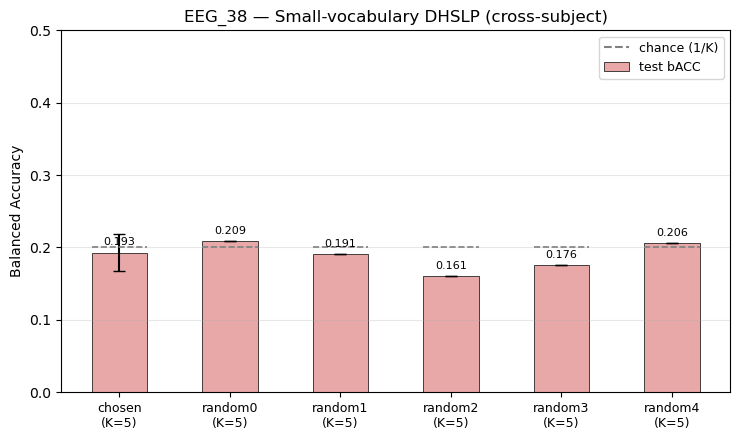

In [7]:
# ====================== §4.1 — Tabella + plot ======================
if 'results' in dir() and results:
    import pandas as pd
    rows = []
    for name, res in results.items():
        tb = np.array([r['test_bacc'] for r in res['seed_res']])
        vb = np.array([r['val_bacc']  for r in res['seed_res']])
        rows.append(dict(config=name, n_cls=res['n_classes'], chance=res['chance'],
                         val_bacc=vb.mean(), test_bacc=tb.mean(), test_std=tb.std(),
                         above_chance=tb.mean()-res['chance']))
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    x = np.arange(len(df)); w = 0.5
    ax.bar(x, df.test_bacc, w, yerr=df.test_std, capsize=4, color='#E8A8A8',
           edgecolor='k', lw=.5, label='test bACC')
    # linea chance per config (5 parole -> 0.20)
    for xi, ch in zip(x, df.chance):
        ax.plot([xi-w/2, xi+w/2], [ch, ch], '--', color='gray', lw=1.2)
    ax.plot([], [], '--', color='gray', label='chance (1/K)')
    ax.set_xticks(x); ax.set_xticklabels(
        [f'{r.config}\n(K={r.n_cls})' for r in df.itertuples()], fontsize=9)
    ax.set_ylabel('Balanced Accuracy'); ax.set_ylim(0, max(0.5, df.test_bacc.max()+0.1))
    ax.set_title('EEG_38 — Small-vocabulary DHSLP (cross-subject)')
    for xi, v in zip(x, df.test_bacc): ax.text(xi, v+0.01, f'{v:.3f}', ha='center', fontsize=8)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=.3)
    plt.tight_layout()
    out = FIG_DIR / 'eeg38_smallvocab.png'
    plt.savefig(out, dpi=150, bbox_inches='tight'); log.info(f'Figura: {out}')
    plt.show()
else:
    print('results non disponibili — esegui §3.1 prima.')

## §5 — Come leggere i risultati

| Esito | Interpretazione |
|-------|-----------------|
| test ≫ chance (es. ≥30% con K=5, chance 20%) | Il **vocabolario era parte del problema**: restringere a poche parole sblocca segnale cross-subject. Forte, da approfondire. |
| test ≈ chance (20%) | Il vocabolario **non** è il collo di bottiglia: anche con 5 parole il segnale cross-subject è assente. Conferma il soffitto informativo (EEG_34/35) e che la letteratura small-vocab è alta perché **subject-specific/small-n**, non cross-subject. |
| `chosen` ≫ `random*` | La scelta di parole "distinte" conta: è un effetto di separabilità semantica, non di vocabolario in sé. |

**Nota onesta**: il subject-specific a 5 parole non è fattibile qui (5 rip/parola/soggetto). Questo
notebook risponde alla versione cross-subject. Per replicare *davvero* il setting della letteratura
servirebbe un dataset con molte ripetizioni di poche parole.